<a href="https://colab.research.google.com/github/DataNata/A-B_testing/blob/main/A_B_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**A/B testing -Эксперимент дизайна карточки продукта на сайте**

Гипотеза теста: на карточке продукта на сайте настроить новый блок с надписью : Гарантированная покупка по оптовым ценам. Мы предполагаем что в группе пользователей которым будут показан товар с новой карточкой - конверсия перехода их в покупку будет выше.

ДИЗАЙН ЭКПЕРИМЕНТА:
1. Сформулировали проблему бизнеса и на ее основе - Гипотезу
2.Определили ключевые метрики и дополнительные:
3.Сформулировать ожидаемый эффект
4.Спрогнозировать сроки проведения экперимента
5.Установить условия окончания теста, критерии успеха и принципы принятия решения

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import seaborn as sns
import matplotlib.pyplot as plt




In [27]:
from typing_extensions import dataclass_transform
# Load the data from the CSV file
data = pd.read_excel('ab_test_data_B2Bshop_2.xlsx')
data.head(5)

,user_id,test_group,created_order,order_sum,geo_region,marketing_group
0,16795,control,0,NaN,city,seo
1,1860,control,0,NaN,region,ppc
2,6390,control,0,NaN,region,email
3,12964,control,0,NaN,city,affiliate
4,12284,control,0,NaN,city,ppc


In [28]:
data.columns


Index(['user_id', 'test_group', 'created_order', 'order_sum', 'geo_region',
       'marketing_group'],
      dtype='object')

С помощью библиотеки seaborn постоим график

In [29]:
def plot_segment(df, segment_column, test_factor):
  for segment in segment_column:
    agregated_data=df.groupby(by=[test_factor, segment]).\
    user_id.count().reset_index()
    sns.catplot(x=segment, y='user_id', hue= test_factor,
                data=agregated_data, kind='bar', height=4,aspect=1.5)


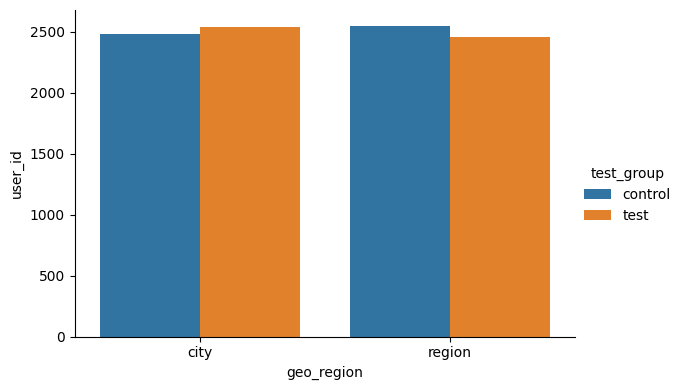

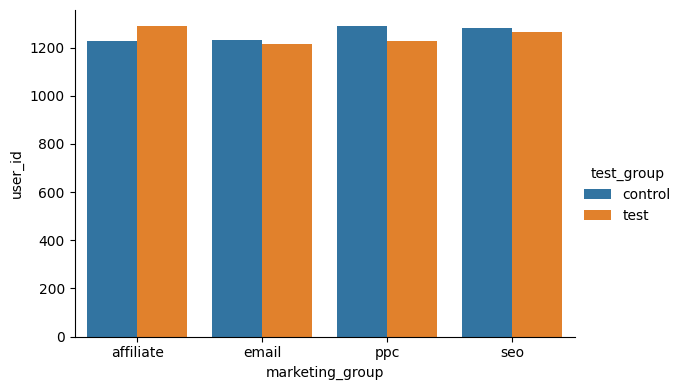

In [30]:
plot_segment(data,['geo_region','marketing_group'], 'test_group')

Мы видим что распределение нормальное

Выведем сводную таблицу с метриками по группам А и Б

In [31]:
metrics= data.groupby("test_group", as_index=False).agg({'user_id': 'count','created_order':'count'})
metrics

,test_group,user_id,created_order
0,control,5030,5030
1,test,4999,4999


In [32]:
metrics = data.groupby("test_group", as_index=False).agg(
    users_count=('user_id', 'count'),
    orders_count=('created_order', 'sum')
)

# Расчет конверсии: заказы / все пользователи в группе
metrics['conversion'] =round( metrics['orders_count'] / metrics['users_count']*100,1)

metrics

,test_group,users_count,orders_count,conversion
0,control,5030,1156,23.0
1,test,4999,1124,22.5


ВЫБЕРЕМ СТАТИСТИЧЕСКИЙ КРИТЕРИЙ , он выбирается исходя из того как распределены наши данные. Разные критерии подходят под разные тесты. Так как у нас выбрана биномиалальная метрика то t-test на не подойдет( он используется для нахождения разницы между средними чеками например). В данном тесте будем использовать Хи-квардра, так как конверсия -биномиальная метрика.


Расчитаем статистическую значимость результата А/Б теста ( т.е. разница между конверсиями двух групп случайна или нет)


Расчет Хи-квадрата

In [33]:
import statsmodels.stats.proportion as proportion

In [34]:
proportion.proportions_chisquare

<function statsmodels.stats.proportion.proportions_chisquare(count, nobs, value=None)>

In [35]:
chi2stat, pval, table=proportion.proportions_chisquare(metrics['orders_count'],metrics['users_count'])

In [36]:
alpha=0.05

In [37]:
print(pval)

0.5521761300522079


In [38]:
print(alpha)

0.05


In [39]:
print(pval<alpha)

False


ВЫВОД : Статистически значимой разницы между конверсиями не обнаружен, так как pvalue выше выбранного порога ошибки первого рода .pvalue показывает с какой вероятностью разница между конверсиями в двух группах случайна - у наз это 55% что выше допустимого нами значения в 5%. Т.е. вероятность того что будет получен результат с Нулевой гипотезой равно 55 %, это больше 5% и у нас нет оснований отклонять нулевую гипотезу.

НО, иожно ли подводить итоги эксперемента сейчас ? Так как в данном эксперементе нам может быть интересена не только метрика КОНВЕРСИЯ, но и метрика СРЕДНИЙ ЧЕК ПОКУПКИ ( так как обычно эти метрики связаны друг с другом : обычно при увеличении конверсии - средний чек падает и наоборот).


Метрика СРЕДНИЙ ЧЕК ПОКУПКИ - НЕ биномиальная, поэтому для нее выбираем критерий стат значимости -BOOTSTRAP


In [2]:
!pip install bootstrapped

  Preparing metadata (setup.py) ... done
  Created wheel for bootstrapped: filename=bootstrapped-0.0.2-py2.py3-none-any.whl size=13932 sha256=02b041f3a262ea926018e7652712e46a3a886a3e8acf1fe56807918fec9e6bdd
  Stored in directory: /root/.cache/pip/wheels/8b/47/d1/909397af2748ea916f6b72c346055e2426e7980bd1894b3633
Successfully built bootstrapped


In [40]:
import bootstrapped.bootstrap as bs
import bootstrapped.stats_functions as bs_stats
import bootstrapped.compare_functions as bs_compare

In [41]:
test= data[data['test_group']=='test']['order_sum'].dropna().values
ctrl= data[data['test_group']=='control']['order_sum'].dropna().values





In [42]:
boot_resalts=bs.bootstrap_ab(test=test, ctrl=ctrl
                             , stat_func=bs_stats.mean
                             ,compare_func=bs_compare.difference
                             ,return_distribution=True
                             )

In [43]:
boot_resalts

array([-1738.56779516, -2831.31221229,  -732.7267228 , ...,
       -3516.64829885, -3015.56694375, -2875.18980833])

In [44]:
border= np.percentile(boot_resalts,[2.5,97.5])
border

array([-4946.69609701,  -339.57879838])

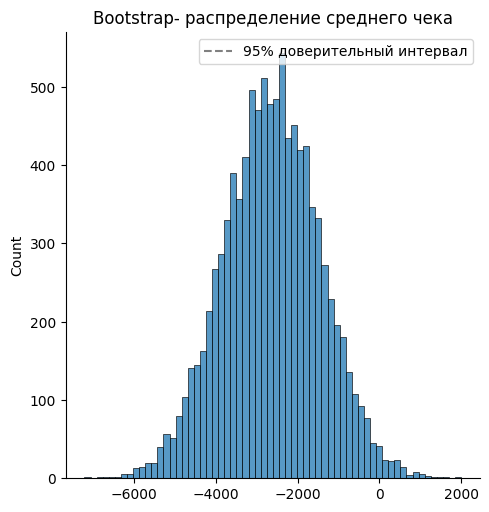

In [45]:
sns.displot(boot_resalts)
plt.title("Bootstrap- распределение среднего чека")
plt.rcParams["figure.figsize"]=(12,6)
plt.vlines(0,ymin=0,ymax=0.003,linestyles='--',colors='red')
plt.vlines(border,ymin=0,ymax=0.003,linestyles='--',colors='grey', label='95% доверительный интервал')
plt.legend()
plt.show()

 В доверительный интервал входит значение 0, а это значит что статистически значимой разницы в среднем чеке мы так же не обнаруживаем. ВЫВОД: никакой статистически значимой разницы НЕТ.

МОЩНОСТЬ теста. Определим ее , что бы понять а был ли у нас вообще шанс увидитеть хоть какую то разницу между тестами)

Мощность - это вероятность увидеть разницу там где она существует.

In [47]:
import statsmodels.stats.power as smp

In [49]:
metrics

,test_group,users_count,orders_count,conversion
0,control,5030,1156,23.0
1,test,4999,1124,22.5


In [50]:
chipower= smp.GofChisquarePower()

In [ ]:
conversion_contril=metrics['conversion'].values[0]/100
conversion_test=metrics['conversion'].values[0]/100
nobs=min(metrics['users_count'])

In [72]:
conversion_control = metrics.loc[metrics['test_group'] == 'control', 'conversion'].values[0] / 100
conversion_test = metrics.loc[metrics['test_group'] == 'test', 'conversion'].values[0] / 100


In [73]:
nobs=min(metrics['users_count'])

In [74]:
def chi2_effect_size(p0,p1):
  return np.sqrt(((p0-p1)**2/p0))

In [75]:
chipower.solve_power(effect_size=chi2_effect_size(conversion_contril,conversion_test),
                     nobs=nobs,
                     alpha=pval,
                     power=None
                     )

np.float64(0.64819974683632)

Мы получили достаточно низкую мощность = 55%, при этом достаточной мощность считается 80% или выше. Таким образом у нас было достаточно мало шансов увидеть статистически значимую разницу в наблюдениях.

Расчет КОЛИЧЕСТВА НАБЛЮДЕНИЙ

Вычислим какое количество наблюдений нужно иметь что бы иметь желаемый уровень мощности в 80% и более

In [81]:
power = 0.8

newsize_test_group = chipower.solve_power(
    effect_size=chi2_effect_size(conversion_contril, conversion_test),
    nobs=None,
    alpha=alpha,
    power=power
)
print('Необходимый размер выборки для эксперимента -{:.0f}'.format(2*newsize_test_group))

Необходимый размер выборки для эксперимента -144419


ВЫВОД: Продолжить экперимент с необходимым количеством наблюдений не менее 144419.